In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# importando parâmetros
struc_par_path = 'parameters/structural.csv'
inter_par_path = 'parameters/interaction.csv'
structural = pd.read_csv(struc_par_path, sep=';', decimal=',')
interaction = pd.read_csv(inter_par_path, sep=';', decimal=',')

R = structural[['Secondary', 'Volume R']].to_numpy()
Q = structural[['Secondary', 'Surface Area Q']].to_numpy()
A = interaction.iloc[:, 1:].to_numpy()

## Implementação UNIFAC

In [ ]:
def get_group_parameters(secondary_groups:np.ndarray, rk:np.ndarray=R, qk:np.ndarray=Q) -> tuple[np.ndarray, np.ndarray]:
    """
    Retrieve UNIFAC group volume and surface area parameters for a set of
    secondary groups.

    The function searches the UNIFAC parameter tables and returns the
    corresponding group volume parameter (Rk) and surface area parameter (Qk)
    for each secondary group provided.

    Parameters
    ----------
    secondary_groups : np.ndarray
        Array containing the secondary group identifiers.
    rk : np.ndarray, optional
        Table containing the group volume parameters. The first column must
        contain the secondary group identifiers and the second column the
        corresponding Rk values.
    qk : np.ndarray, optional
        Table containing the group surface area parameters. The first column
        must contain the secondary group identifiers and the second column the
        corresponding Qk values.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Tuple containing:

        - r : np.ndarray
            Group volume parameters (Rk) associated with each secondary group.
        - q : np.ndarray
            Group surface area parameters (Qk) associated with each secondary
            group.
    """
    # Ordenando vetores com base nos grupos secundários
    rk = rk[np.argsort(rk[:, 0])]
    qk = qk[np.argsort(qk[:, 0])]
    # Buscando parâmetros dos grupos secundários fornecidos
    r = rk[np.searchsorted(rk[:, 0], secondary_groups), 1]
    q = qk[np.searchsorted(qk[:, 0], secondary_groups), 1]
    return r, q


def assemble_interaction_matrix(species:dict, temperature:float, amn:np.ndarray=A) -> np.ndarray:
    """
    Assemble the UNIFAC group interaction matrix for the groups present in a
    mixture.

    The function identifies all unique secondary groups present in the species,
    retrieves the corresponding main groups, and computes the interaction
    parameter matrix Ψmn from the UNIFAC interaction energy parameters.

    Parameters
    ----------
    species : dict
        Dictionary containing the molecular structures. Each species must be
        represented as an iterable of groups in the format
        [main_group, secondary_group, quantity].
    temperature : float
        System temperature in Kelvin.
    amn : np.ndarray, optional
        Matrix of UNIFAC interaction energy parameters. Element (m, n)
        corresponds to the interaction parameter a_mn between main groups.

    Returns
    -------
    np.ndarray
        Square matrix containing the interaction parameters Ψmn for all
        unique groups present in the mixture.
    """
    # Obtendo todos os grupos
    groups = np.array(sorted({
        (group[0], group[1])
        for molecule in species.values()
        for group in molecule
    }))
    # Índices dos grupos na tabela amn
    main_groups = groups[:, 0] - 1
    # Calculando parâmetro de interação com base no parâmetro de energia     
    psi_mn = np.exp(-amn[np.ix_(main_groups, main_groups)] / temperature)
    return psi_mn


def assemble_groups_matrix(species:dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Construct the UNIFAC group incidence matrix for a set of species.

    The function identifies all unique secondary groups present in the mixture
    and builds a matrix containing the number of occurrences of each group in
    each species. Each row corresponds to a secondary group and each column
    corresponds to a species.

    Parameters
    ----------
    species : dict
        Dictionary containing the molecular structures. Each species must be
        represented as an iterable of groups in the format
        [main_group, secondary_group, quantity].

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Tuple containing:

        - unique_sec : np.ndarray
            Sorted array of unique secondary group identifiers present in the
            mixture.
        - arr : np.ndarray
            Group incidence matrix. Element (k, i) corresponds to the number
            of occurrences of secondary group k in species i.
    """
    # Montando arrays com grupos secundários
    data = np.array([
        [i, group[1], group[2]]
        for i, molecule in enumerate(species.values())
        for group in molecule
    ])
    # Obtendo grupos secundários únicos
    unique_sec = np.sort(np.unique(data[:, 1]))
    # Matriz de resposta
    arr = np.zeros((len(unique_sec), len(species)), dtype=int) 
    # Índices das linhas em data que contém os grupos secundários
    row_idx = np.searchsorted(unique_sec, data[:, 1])
    # Coluna i = espécie i
    col_idx = data[:, 0]
    # Montando matriz com valores de v_k
    arr[row_idx, col_idx] = data[:, 2]
    return unique_sec, arr


def combinatorial_contribution(composition:np.ndarray, group_matrix:np.ndarray, rk:np.ndarray, qk:np.ndarray, z:int) -> np.ndarray:
    """
    Calculate the combinatorial contribution to the activity coefficient using
    the UNIFAC formulation.

    The combinatorial contribution accounts for differences in molecular size
    and shape through the species volume, surface area, and structural
    parameters.

    Parameters
    ----------
    composition : np.ndarray
        Mole fraction of each species in the mixture.
    group_matrix : np.ndarray
        Group incidence matrix. Element (k, i) corresponds to the number of
        occurrences of group k in species i.
    rk : np.ndarray
        Group volume parameters (Rk) for the groups present in the mixture.
    qk : np.ndarray
        Group surface area parameters (Qk) for the groups present in the
        mixture.
    z : int
        Coordination number used in the combinatorial term.

    Returns
    -------
    np.ndarray
        Natural logarithm of the combinatorial contribution to the activity
        coefficient for each species.
    """
    ri = rk @ group_matrix
    qi = qk @ group_matrix
    li = z/2 * (ri - qi) - (ri - 1)
    # Calculo de phi_i
    den_phi = composition @ ri
    phi_i = (composition * ri) / den_phi
    # Calculo de theta_i
    den_theta = composition @ qi
    theta_i = (composition * qi) / den_theta
    # Ponderação de li
    l_mix = composition @ li
    # Contribuição combinatorial
    ln_comb = (
        np.log(phi_i/composition)
        + (z/2) * qi * np.log(theta_i/phi_i)
        + li
        - (phi_i/composition) * l_mix
    )
    return ln_comb


def calculate_group_lngamma(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray) -> np.ndarray:
    """
    Calculate the logarithm of the group activity coefficients for a given
    composition.

    The function evaluates the group activity coefficient expression used in
    the UNIFAC residual contribution. It can be applied to either a single
    mixture composition or multiple compositions simultaneously.

    Parameters
    ----------
    composition : np.ndarray
        Species mole fractions. May be provided as a one-dimensional array
        of shape (n_species,) or as a two-dimensional array of shape
        (n_cases, n_species).
    groups_matrix : np.ndarray
        Group incidence matrix. Element (k, i) corresponds to the number of
        occurrences of group k in species i.
    qk : np.ndarray
        Group surface area parameters (Qk) for the groups present in the
        mixture.
    interaction_matrix : np.ndarray
        Matrix of UNIFAC interaction parameters Ψmn between groups.

    Returns
    -------
    np.ndarray
        Natural logarithm of the group activity coefficients. The returned
        array has shape (n_cases, n_groups), where each row corresponds to a
        mixture composition and each column corresponds to a group.

    Notes
    -----
    This function evaluates the group activity coefficient term, ln(Γk),
    required for the calculation of the residual contribution to the activity
    coefficient. The same implementation can be used for both the actual
    mixture composition and the reference solutions employed by the UNIFAC
    model.
    """
    composition = np.atleast_2d(composition)
    # Calculando Xk
    arr_sum = groups_matrix.sum(axis=0)
    den = composition @ arr_sum
    xk = (composition @ groups_matrix.T) / den[:, None]
    
    # Calculando Theta_m
    den_theta = xk @ qk
    theta_m = (xk * qk) / den_theta[:, None]

    # Calculando ln Gamma i
    den = theta_m @ interaction_matrix
    term1 = np.log(den)
    term2 = (
        (interaction_matrix[None, :, :] * theta_m[:, None, :]) / den[:, None, :]
    ).sum(axis=2)
    ln_gamma = qk * (1 - term1 - term2)
    return ln_gamma


def residual_contribution(composition:np.ndarray, groups_matrix:np.ndarray, qk:np.ndarray, interaction_matrix:np.ndarray) -> np.ndarray:
    """
    Calculate the residual contribution to the activity coefficient using the
    UNIFAC model.

    The residual contribution accounts for energetic interactions between
    functional groups. It is obtained from the difference between the group
    activity coefficients in the actual mixture and in the UNIFAC reference
    solutions.

    Parameters
    ----------
    composition : np.ndarray
        Mole fraction of each species in the mixture.
    groups_matrix : np.ndarray
        Group incidence matrix. Element (k, i) corresponds to the number of
        occurrences of group k in species i.
    qk : np.ndarray
        Group surface area parameters (Qk) for the groups present in the
        mixture.
    interaction_matrix : np.ndarray
        Matrix of UNIFAC interaction parameters Ψmn between groups.

    Returns
    -------
    np.ndarray
        Natural logarithm of the residual contribution to the activity
        coefficient for each species.

    Notes
    -----
    The reference solutions are defined as pure-component solutions, where
    each species is considered separately. The residual contribution is
    computed as:

        ln(γᵢᴿ) = Σ νₖ⁽ⁱ⁾ [ln(Γₖ) - ln(Γₖ⁽ⁱ⁾)]

    where ln(Γₖ) is evaluated for the actual mixture composition and
    ln(Γₖ⁽ⁱ⁾) is evaluated for the reference solution of species i.
    """
    # Calculando ln(Γk) para a composição da mistura
    ln_gamma = calculate_group_lngamma(
        composition,
        groups_matrix,
        qk,
        interaction_matrix
    )
    # Calculando ln(Γk^(i)) para as soluções padrão
    ln_gamma_std = calculate_group_lngamma(
        np.identity(groups_matrix.shape[1]),
        groups_matrix,
        qk,
        interaction_matrix
    )
    # Diferença entre a solução real e as soluções padrão
    delta = ln_gamma - ln_gamma_std
    # Calculando a contribuição residual de cada espécie
    ln_res = np.sum(
        groups_matrix.T * delta,
        axis=1
    )
    return ln_res


def unifac(species:dict, composition:np.ndarray, temperature:float, z=10) -> np.ndarray:
    """
    Calculate activity coefficients using the UNIFAC method.

    The calculation is performed by combining the combinatorial and residual
    contributions to the activity coefficient according to the UNIFAC
    formulation.

    Parameters
    ----------
    species : dict
        Dictionary containing the molecular structures. Each species must be
        represented as an iterable of groups in the format
        [main_group, secondary_group, quantity].
    composition : np.ndarray
        Mole fraction of each species in the mixture.
    temperature : float
        System temperature in Kelvin.
    z : int, optional
        Coordination number used in the combinatorial contribution. The
        default value is 10.

    Returns
    -------
    np.ndarray
        Natural logarithm of the activity coefficient for each species.
    """
    # Montando a matriz de grupos presentes nas espécies
    unique, group_matrix = assemble_groups_matrix(species)
    # Obtendo os parâmetros estruturais dos grupos (Rk e Qk)
    r, q = get_group_parameters(unique)
    # Calculando a contribuição combinatorial
    ln_gamma_comb = combinatorial_contribution(composition, group_matrix, r, q, z)
    # Calculando os parâmetros de interação entre grupos (Ψmn)
    psi = assemble_interaction_matrix(species, temperature)
    # Calculando a contribuição residual
    ln_gamma_res = residual_contribution(composition, group_matrix, q, psi)
    # Coeficiente de atividade total
    return ln_gamma_res + ln_gamma_comb


# Função auxiliar para lidar com vetores de composição -> [n_pontos, n_espécies]
def unifac_vetorized(species:dict, composition:np.ndarray, temperature:float, z=10) -> np.ndarray:
    """
    Evaluate the UNIFAC model for multiple mixture compositions.

    This function is a convenience wrapper around ``unifac`` that applies the
    model to a collection of compositions and stores the results in a single
    array.

    Parameters
    ----------
    species : dict
        Dictionary containing the molecular structures. Each species must be
        represented as an iterable of groups in the format
        [main_group, secondary_group, quantity].
    composition : np.ndarray
        Array of species mole fractions with shape (n_points, n_species).
        Each row corresponds to a mixture composition.
    temperature : float
        System temperature in Kelvin.
    z : int, optional
        Coordination number used in the combinatorial contribution. The
        default value is 10.

    Returns
    -------
    np.ndarray
        Natural logarithm of the activity coefficients for each composition.
        The returned array has shape (n_points, n_species).
    """
    # Matriz para armazenar os coeficientes de atividade calculados
    ln_gammas = np.zeros(composition.shape)
    # Avaliando o modelo para cada composição
    for i, row in enumerate(composition):
        ln_gammas[i, :] = unifac(species, row, temperature)
    return ln_gammas

In [4]:
# Definindo parâmetros
temperatura = 307  # K
composicao = np.array([0.047, 0.953])

# Definindo moléculas e seus grupos
# Espécie1: [
#      [Main Group, Secondary Group, Qty]1,
#      [Main Group, Secondary Group, Qty]2,
#   ]
especies = {
    "1": [
        [1, 1 , 1],
        [9, 18, 1],
    ],
    "2": [
        [1, 1, 2],
        [1, 2, 3],
    ]
}


In [5]:
# Teste exemplo Reid and Prausnitz
ln_gammas = unifac(especies, composicao, temperatura)
print(f'gamma_acetona: {np.exp(ln_gammas[0])}')
print(f'gamma_n-pentano: {np.exp(ln_gammas[1])}')

gamma_acetona: 4.992034311484558
gamma_n-pentano: 1.005260211187879


## Exemplo dados reais

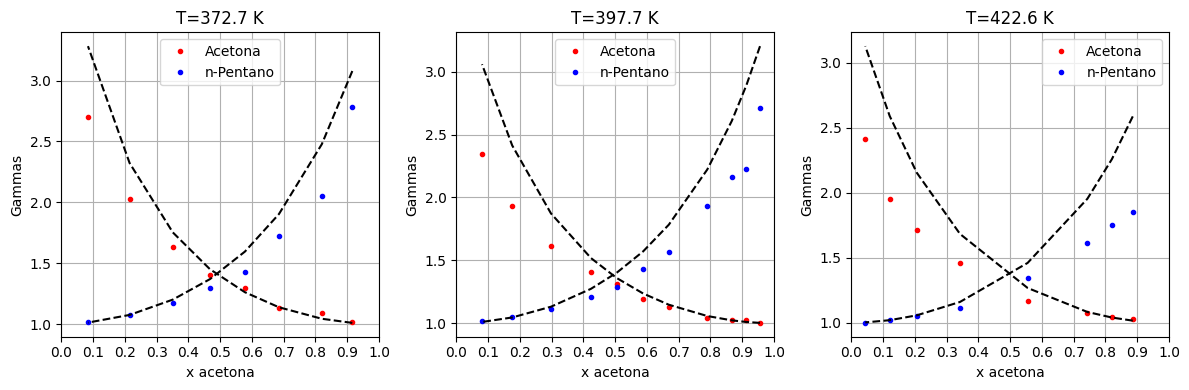

In [6]:
# Importando valores experimentais
with open('dados experimentais/acetona_n-pentano.json', 'r') as file:
    data = json.load(file)

# Criando gráficos
fig, ax = plt.subplots(1, len(data['Data']), figsize=(12, 4))

for i, v in enumerate(data['Data'].values()):
    temperatura = v['T [K]']
    x1 = np.array(v['x_acetona'])
    composicao = np.stack((x1, 1-x1), axis=1)
    g1_exp = np.exp(np.array(v['lng_acetona']))
    g2_exp = np.exp(np.array(v['lng_npentano']))
    # Resolvendo UNIFAC para frações molares experimentais
    gammas_unifac = np.exp(unifac_vetorized(especies, composicao, temperatura))

    # Plotando resultados
    ax[i].plot(x1, g1_exp, '.r', label='Acetona')
    ax[i].plot(x1, g2_exp, '.b', label='n-Pentano')
    ax[i].plot(x1, gammas_unifac[:, 0], '--k')
    ax[i].plot(x1, gammas_unifac[:, 1], '--k')
    ax[i].set_xticks(np.linspace(0, 1, 11))
    ax[i].grid()
    ax[i].set_title(f'T={temperatura} K')
    ax[i].set_xlabel('x acetona')
    ax[i].set_ylabel('Gammas')
    ax[i].legend()

plt.tight_layout()
plt.show()


## Exemplo 2: Sistema Etanol + 2-butanona

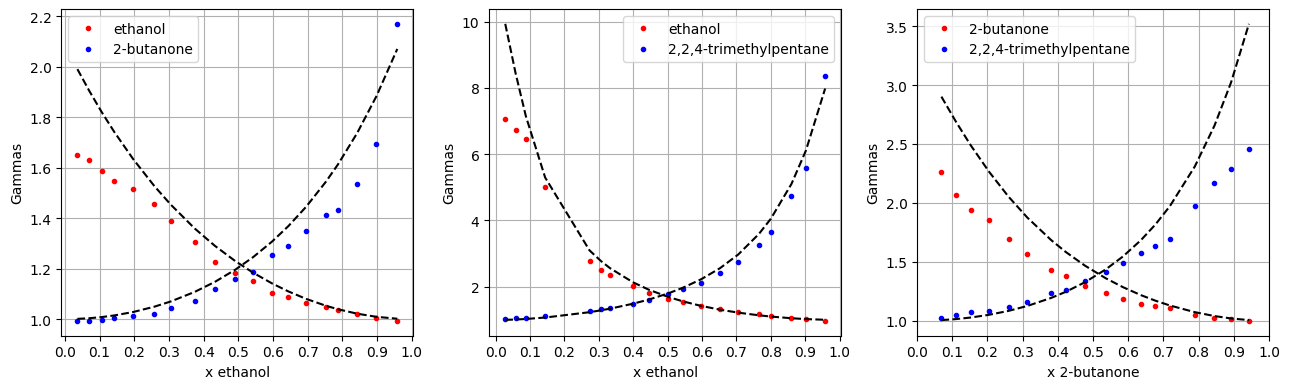

In [7]:
# Importando valores experimentais
with open('dados experimentais/etanol_2-butanona_224-trimetilpentano.json', 'r') as file:
    data = json.load(file)

etanol = [
        [1, 1 , 1], # CH3
        [1, 2 , 1], # CH2
        [5, 14, 1], # OH
    ]

butanona = [
        [1, 1, 1],  # CH3
        [1, 2, 1],  # CH2
        [9, 18, 1], # CH3CO
    ]

trimetilpentano = [
    [1, 1, 5], # CH3
    [1, 2, 1], # CH2
    [1, 3, 1], # CH
    [1, 4, 1], # C
]
especies1 = {
    "1": etanol,
    "2": butanona
}
especies2 = {
    "1": etanol,
    "2": trimetilpentano 
}
especies3 = {
    "1": butanona,
    "2": trimetilpentano 
}
binarios = [especies1, especies2, especies3]

# Criando gráficos
fig, ax = plt.subplots(1, len(binarios), figsize=(13, 4))

for k, esp in enumerate(binarios):
    dados = data['Data'][str(k + 1)]
    temperaturas = np.array(dados['T [K]'])
    x1 = np.array(dados['x_1'])
    composicao = np.stack((x1, 1-x1), axis=1)
    g1_exp = np.array(dados['gamma_1'])
    g2_exp = np.array(dados['gamma_2'])

    gammas_unifac = np.zeros(composicao.shape)
    for i, row in enumerate(composicao):
        # Resolvendo UNIFAC para frações molares experimentais
        gammas_unifac[i, :] = np.exp(unifac(esp, row, temperaturas[i]))

    
    # Plotando resultados
    sp1, sp2 = dados['especies'].split(' + ')
    ax[k].plot(x1, g1_exp, '.r', label=sp1)
    ax[k].plot(x1, g2_exp, '.b', label=sp2)
    ax[k].plot(x1, gammas_unifac[:, 0], '--k')
    ax[k].plot(x1, gammas_unifac[:, 1], '--k')
    ax[k].set_xticks(np.linspace(0, 1, 11))
    ax[k].grid()
    ax[k].set_xlabel(f'x {sp1}')
    ax[k].set_ylabel('Gammas')
    ax[k].legend()

plt.tight_layout()
plt.show()


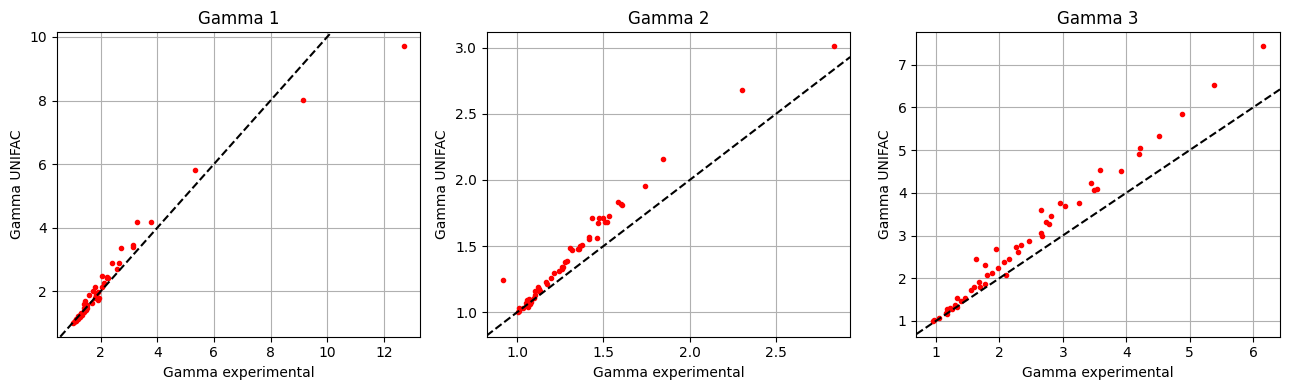

In [8]:
# Ternario
especies = {
    "1": etanol,
    "2": butanona,
    "3": trimetilpentano
}
dados_ternario = data['Data']['4']
temperaturas = np.array(dados_ternario['T [K]'])
x1 = np.array(dados_ternario['x_1'])
x2 = np.array(dados_ternario['x_2'])
composicao = np.stack((x1, x2, 1-x1-x2), axis=1)
g1_exp = np.array(dados_ternario['gamma_1'])
g2_exp = np.array(dados_ternario['gamma_2'])
g3_exp = np.array(dados_ternario['gamma_3'])

gammas_unifac = np.zeros(composicao.shape)
for i, row in enumerate(composicao):
    # Resolvendo UNIFAC para frações molares experimentais
    gammas_unifac[i, :] = np.exp(unifac(especies, row, temperaturas[i]))

fig, ax = plt.subplots(1, len(gammas_unifac.T), figsize=(13, 4))

for i, g_exp in enumerate([g1_exp, g2_exp, g3_exp]):
    ax[i].plot(g_exp, gammas_unifac[:, i], '.r')
    ax[i].axline((min(g_exp), min(g_exp)), slope=1, color='black', linestyle='--')
    ax[i].set_title(f'Gamma {i + 1}')
    ax[i].grid()
    ax[i].set_xlabel('Gamma experimental')
    ax[i].set_ylabel('Gamma UNIFAC')

plt.tight_layout()
plt.show()